###  BB PSD



### 1. Input: sign-flip noise maps
Each sign-flip realization $i$ provides Q and U maps with the CMB signal cancelled,
leaving only noise:
$$\tilde{Q}^{(i)}(\hat{n}), \quad \tilde{U}^{(i)}(\hat{n})$$

### 2. Apply apodisation mask
Multiply by the weight mask $w(\hat{n}) \in [0, 1]$:
$$\tilde{Q}^{(i)}_w = w(\hat{n})\,\tilde{Q}^{(i)}, \qquad \tilde{U}^{(i)}_w = w(\hat{n})\,\tilde{U}^{(i)}$$

Unobserved and masked pixels are set to zero.

### 3. Spherical harmonic transform → pseudo-$C_\ell$
`hp.anafast` decomposes the masked Q/U into spin-2 spherical harmonics and returns the
**pseudo**-$C_\ell$ (no mask mode-coupling correction, no beam correction):
$$\tilde{C}^{BB,(i)}_\ell = \frac{1}{2\ell+1}\sum_m \left|\tilde{a}^{B,(i)}_{\ell m}\right|^2$$

### 4. Average over $N$ sign-flip realizations
$$N_\ell = \frac{1}{N}\sum_{i=1}^{N} \tilde{C}^{BB,(i)}_\ell$$

Averaging reduces the variance on the noise estimate. More sign-flips → smoother curve.

### 5. Convert to $D_\ell$
$$D_\ell^{BB} = \frac{\ell(\ell+1)}{2\pi}\,N_\ell$$

### 6. Unit conversion
| Source | Map unit | $C_\ell$ unit | Factor applied | $D_\ell$ unit |
|--------|----------|---------------|----------------|---------------|
| G3     | mK       | mK²           | $\times 10^6$  | μK²           |
| FITS   | μK       | μK²           | $\times 1$     | μK²           |

### What this is NOT
- Not corrected for the mask mode-coupling matrix $M_{\ell\ell'}$
- Not beam-deconvolved
- Pure noise estimate — signal is cancelled by construction in sign-flip maps


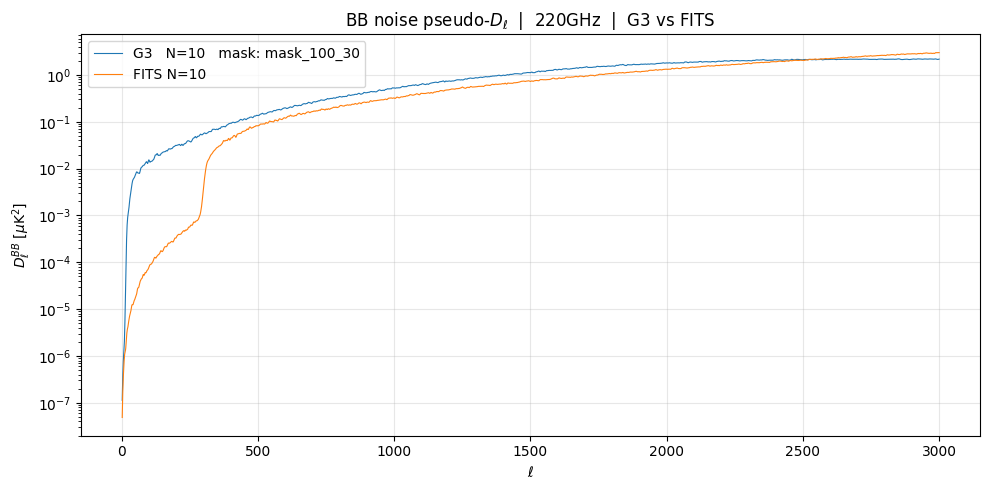

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_G3   = os.path.expanduser("~/Initial_test/Code/Map_Operation/outputs/noise_psd_BB_g3_220ghz.npz")
OUT_FITS = os.path.expanduser("~/Initial_test/outputs/noise_psd_BB_fits_220ghz.npz")

# Load G3
d_g3  = np.load(OUT_G3, allow_pickle=True)
ell_g3 = d_g3['ell']
D_g3  = ell_g3 * (ell_g3 + 1) * d_g3['N_l'] * 1e6 / (2 * np.pi) 
N_g3   = int(d_g3['N'])
mask_g3 = str(d_g3['mask'])

# Load FITS
d_fits  = np.load(OUT_FITS, allow_pickle=True)
ell_fits = d_fits['ell']
D_fits = ell_fits * (ell_fits + 1) * d_fits['N_l'] / (2 * np.pi)
N_fits   = int(d_fits['N'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ell_g3[2:],   D_g3[2:],   lw=0.8, label=f"G3   N={N_g3}   mask: {mask_g3}")
ax.plot(ell_fits[2:], D_fits[2:], lw=0.8, label=f"FITS N={N_fits}")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell^{BB}\ [\mu\mathrm{K}^2]$")
ax.set_title("BB noise pseudo-$D_\\ell$  |  220GHz  |  G3 vs FITS")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



So this thing is the average noise spectrum computed by 